# Análisis del Target: NO2

Aquí analizamos en profundidad nuestra variable objetivo (NO2), trabajando **solo con `train.csv`** .

**Qué vamos a ver:**
1. Distribución (histograma, ¿simétrica o asimétrica?)
2. Estadísticos básicos
3. Detección de outliers (IQR y Z-score)
4. Variación temporal (mes, día de la semana)
5. Variación por estación de medición

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ruta = "../data_sample/"
train = pd.read_parquet(ruta + "train.parquet")

print("Train:", train.shape)
train["no2"].describe()

Train: (40800, 16)


count    40800.000000
mean        28.138529
std         16.958338
min          1.000000
25%         15.000000
50%         24.000000
75%         37.000000
max        148.000000
Name: no2, dtype: float64

## 1. Distribución del target

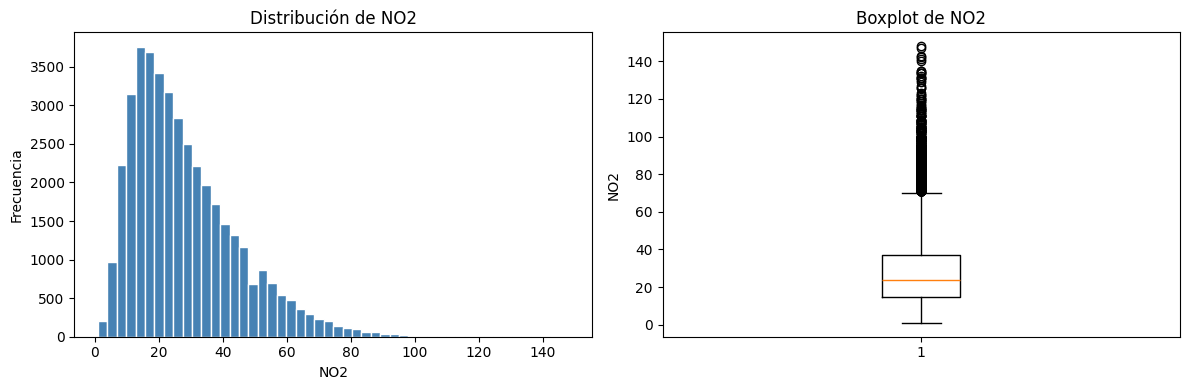

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma: para ver la forma de la distribucion
axes[0].hist(train["no2"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Distribución de NO2")
axes[0].set_xlabel("NO2")
axes[0].set_ylabel("Frecuencia")

# Boxplot: para ver la mediana, los cuartiles y los outliers de un vistazo
axes[1].boxplot(train["no2"], vert=True)
axes[1].set_title("Boxplot de NO2")
axes[1].set_ylabel("NO2")

plt.tight_layout()
plt.show()

**¿Qué significa esto?**

- **Histograma**: cada barra representa cuántos días tuvieron un nivel de NO2 en ese rango. Si la mayoría de barras están a la izquierda y hay una "cola" larga hacia la derecha, la distribución está **sesgada a la derecha** (asimétrica) — es habitual en variables de contaminación, porque hay muchos días "normales" y pocos días con picos muy altos.

- **Boxplot** (diagrama de caja): la caja representa donde está el 50% central de los datos, la línea del medio es la mediana, y los puntos sueltos por encima o por debajo de los "bigotes" son los outliers — valores que se salen claramente de lo normal.

In [3]:
media = train["no2"].mean()
mediana = train["no2"].median()
asimetria = train["no2"].skew()

print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Asimetria (skew): {asimetria:.2f}")

Media: 28.14
Mediana: 24.00
Asimetria (skew): 1.23




- Si **media > mediana** → hay una cola de valores altos tirando de la media hacia arriba (sesgo a la derecha)
- **Asimetría (skew)**: es un número que resume la forma de la distribución
  - Cerca de 0 → simétrica
  - Mayor que 0 → sesgada a la derecha (cola larga hacia valores altos)
  - Menor que 0 → sesgada a la izquierda

  Como referencia: valores entre -0.5 y 0.5 se consideran razonablemente simétricos; por encima de 1 (en valor absoluto) ya es una asimetría marcada. Esto es información útil para el equipo de preprocesado: si el target está muy sesgado, podrían plantearse aplicar una transformación (ej. logaritmo) antes de modelar.

## 2. Detección de outliers

In [4]:
# Metodo IQR (rango intercuartilico)
q1 = train["no2"].quantile(0.25)
q3 = train["no2"].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers_iqr = train[(train["no2"] < limite_inferior) | (train["no2"] > limite_superior)]

print(f"Q1: {q1:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}")
print(f"Limite inferior: {limite_inferior:.2f}, Limite superior: {limite_superior:.2f}")
print(f"Numero de outliers (IQR): {len(outliers_iqr)} de {len(train)} ({len(outliers_iqr)/len(train)*100:.1f}%)")

Q1: 15.00, Q3: 37.00, IQR: 22.00
Limite inferior: -18.00, Limite superior: 70.00
Numero de outliers (IQR): 935 de 40800 (2.3%)


**¿Qué significa esto?** El método IQR (rango intercuartílico) mira dónde está el 50% central de los datos (entre Q1 y Q3) y marca como outlier todo lo que se aleje demasiado de ahí (1.5 veces el ancho de ese rango central, por encima o por debajo). Es el mismo criterio que usa el boxplot de arriba para dibujar los puntos sueltos.

In [5]:
# Metodo Z-score (cuantas desviaciones estandar se aleja cada valor de la media)
media = train["no2"].mean()
desviacion = train["no2"].std()

z_scores = (train["no2"] - media) / desviacion
outliers_zscore = train[z_scores.abs() > 3]

print(f"Numero de outliers (Z-score > 3): {len(outliers_zscore)} de {len(train)} ({len(outliers_zscore)/len(train)*100:.1f}%)")

Numero de outliers (Z-score > 3): 442 de 40800 (1.1%)


**¿Qué significa esto?** El Z-score mide cuántas "desviaciones estándar" se aleja cada valor de la media. Por ejemplo, un Z-score de 3 significa que ese valor está muy lejos de lo normal (en una distribución simétrica, solo el 0.3% de los datos deberían tener un Z-score mayor que 3). Por eso usamos ese 3 como límite para marcar outliers.



## 3. Variación temporal

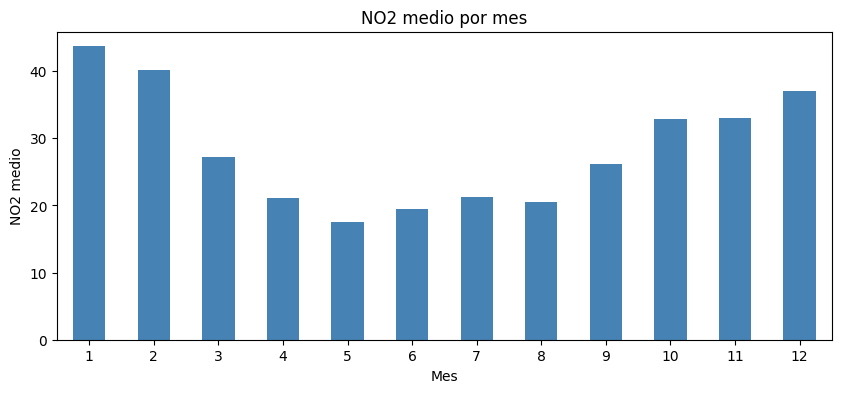

In [6]:
# Creamos columnas auxiliares a partir de la fecha
train["mes"] = train["fecha"].dt.month
train["dia_semana"] = train["fecha"].dt.day_name()
train["es_fin_de_semana"] = train["fecha"].dt.dayofweek >= 5  # 5=sabado, 6=domingo

no2_por_mes = train.groupby("mes")["no2"].mean()

plt.figure(figsize=(10, 4))
no2_por_mes.plot(kind="bar", color="steelblue")
plt.title("NO2 medio por mes")
plt.xlabel("Mes")
plt.ylabel("NO2 medio")
plt.xticks(rotation=0)
plt.show()

**¿Qué significa esto?** Creamos 3 columnas nuevas a partir de la fecha (mes, nombre del día de la semana, y si es fin de semana), y agrupamos el NO2 por mes para ver si hay estacionalidad. Es habitual que la contaminación sea más alta en invierno (más calefacción, menos dispersión del aire) y más baja en verano — este gráfico nos dice si eso se cumple también en Madrid con nuestros datos.

Día laboral      29.904141
Fin de semana    23.760788
Name: no2, dtype: float64


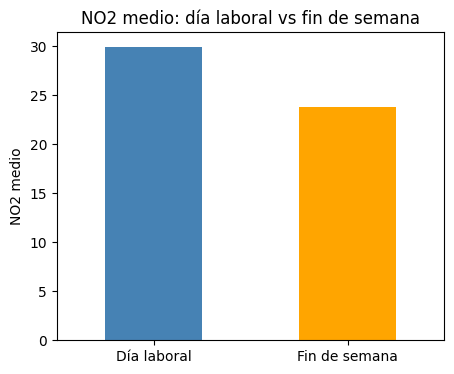

In [7]:
no2_finde_vs_laboral = train.groupby("es_fin_de_semana")["no2"].mean()
no2_finde_vs_laboral.index = ["Día laboral", "Fin de semana"]

print(no2_finde_vs_laboral)

plt.figure(figsize=(5, 4))
no2_finde_vs_laboral.plot(kind="bar", color=["steelblue", "orange"])
plt.title("NO2 medio: día laboral vs fin de semana")
plt.ylabel("NO2 medio")
plt.xticks(rotation=0)
plt.show()

**¿Qué significa esto?** Comparamos el NO2 medio entre días laborales y fines de semana. Si nuestra hipótesis de negocio es correcta (más tráfico → más NO2), esperaríamos ver un NO2 más bajo el fin de semana, cuando hay menos coches circulando — sobre todo menos tráfico de "ir a trabajar".

## 4. Variación por estación de medición

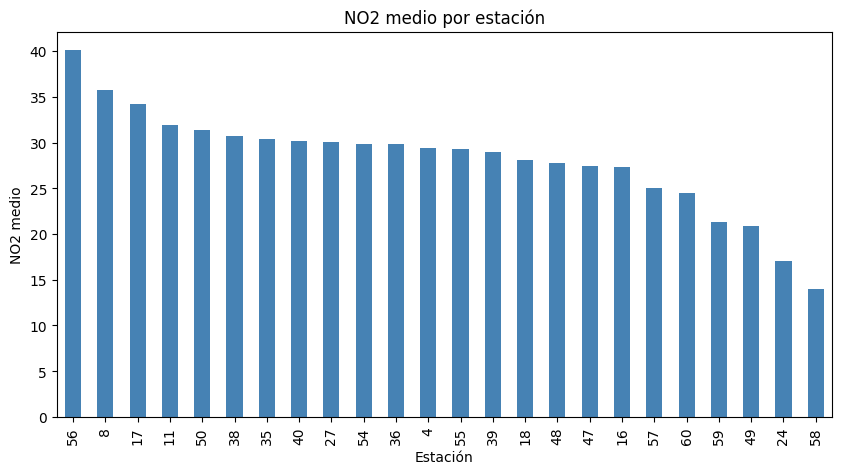

In [8]:
no2_por_estacion = train.groupby("estacion")["no2"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
no2_por_estacion.plot(kind="bar", color="steelblue")
plt.title("NO2 medio por estación")
plt.xlabel("Estación")
plt.ylabel("NO2 medio")
plt.show()

**¿Qué significa esto?** Cada barra es una estación de medición (24 en total), ordenadas de más a menos contaminada de media. Esto nos dice si hay zonas de Madrid sistemáticamente más contaminadas que otras (probablemente las de más tráfico, como Plaza Elíptica o la M30, frente a zonas más residenciales o parques como El Pardo).

## 5. Relación tráfico vs. NO2

Ahora cambiamos de pregunta: ya no miramos el target solo, sino cómo se relaciona con cada feature. Empezamos por el tráfico.

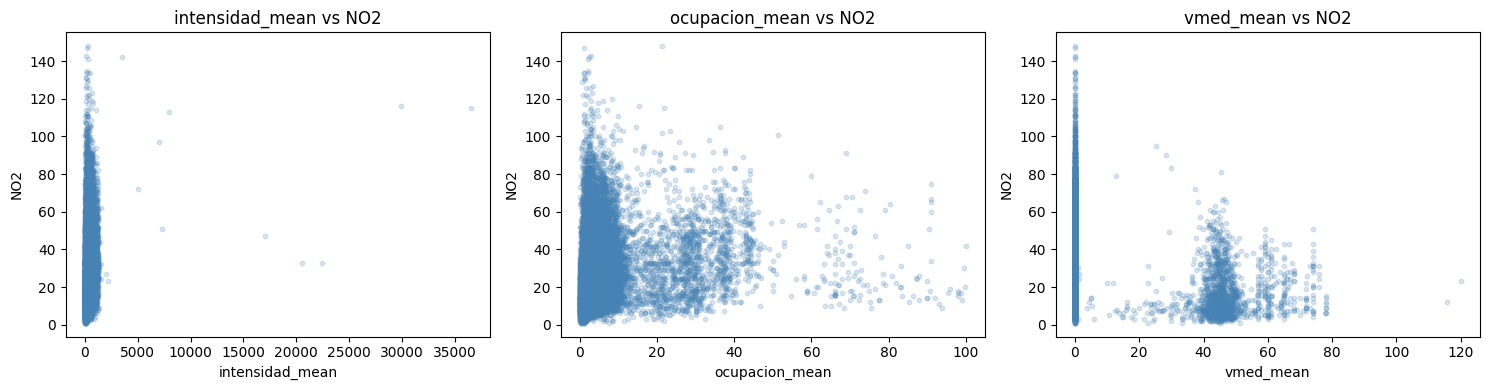

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

variables_trafico = ["intensidad_mean", "ocupacion_mean", "vmed_mean"]

for ax, variable in zip(axes, variables_trafico):
    ax.scatter(train[variable], train["no2"], alpha=0.2, s=10, color="steelblue")
    ax.set_xlabel(variable)
    ax.set_ylabel("NO2")
    ax.set_title(f"{variable} vs NO2")

plt.tight_layout()
plt.show()

**¿Qué significa esto?** Un scatter plot pone un punto por cada día: en el eje X la variable de tráfico, en el eje Y el NO2 de ese mismo día. Si los puntos forman una nube que sube de izquierda a derecha, hay relación positiva (más tráfico, más NO2). Si la nube es plana o dispersa sin forma clara, la relación es débil o inexistente.


In [10]:
correlacion_trafico = train[["no2"] + variables_trafico].corr()["no2"].drop("no2")
correlacion_trafico.sort_values(ascending=False)

intensidad_mean    0.150378
ocupacion_mean     0.139435
vmed_mean         -0.157647
Name: no2, dtype: float64

**¿Qué significa esto?** La correlación es un número entre -1 y 1 que resume qué tan fuerte y en qué dirección se relacionan dos variables:
- Cerca de **+1** → cuando una sube, la otra también sube (relación positiva fuerte)
- Cerca de **-1** → cuando una sube, la otra baja (relación negativa fuerte)
- Cerca de **0** → apenas hay relación lineal entre ellas

Como referencia orientativa: por debajo de 0.3 (en valor absoluto) se suele considerar una relación débil; entre 0.3 y 0.6, moderada; por encima de 0.6, fuerte. Esto nos dice qué variables de tráfico están más ligadas al NO2, información clave para saber qué features van a aportar más al modelo.

## 6. Relación meteorología vs. NO2

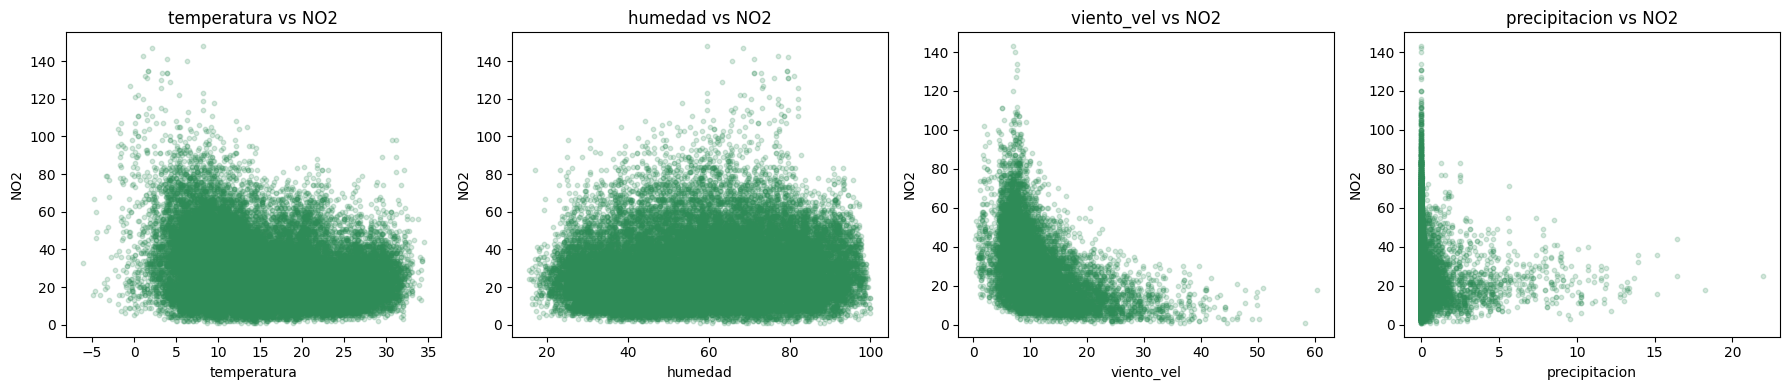

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

variables_meteo = ["temperatura", "humedad", "viento_vel", "precipitacion"]

for ax, variable in zip(axes, variables_meteo):
    ax.scatter(train[variable], train["no2"], alpha=0.2, s=10, color="seagreen")
    ax.set_xlabel(variable)
    ax.set_ylabel("NO2")
    ax.set_title(f"{variable} vs NO2")

plt.tight_layout()
plt.show()

In [12]:
correlacion_meteo = train[["no2"] + variables_meteo].corr()["no2"].drop("no2")
correlacion_meteo.sort_values(ascending=False)

humedad          0.133002
precipitacion   -0.083267
temperatura     -0.281485
viento_vel      -0.488114
Name: no2, dtype: float64

**¿Qué significa esto?** Aquí buscamos patrones conocidos del mundo real, para comprobar si los datos los reflejan:
- **Viento**: se espera una correlación **negativa** (más viento, "limpia" el aire, menos NO2 acumulado)
- **Precipitación**: también se espera negativa (la lluvia arrastra partículas y contaminantes)
- **Temperatura**: la relación es menos directa — en invierno hay más calefacción (sube NO2) pero también más ventilación en verano; puede no salir una relación lineal clara



## Resumen de correlaciones con el target

In [13]:
todas_las_features = variables_trafico + variables_meteo
resumen_correlacion = train[["no2"] + todas_las_features].corr()["no2"].drop("no2").sort_values(key=abs, ascending=False)

print("Features ordenadas por fuerza de relacion con NO2 (de mas a menos fuerte):")
resumen_correlacion

Features ordenadas por fuerza de relacion con NO2 (de mas a menos fuerte):


viento_vel        -0.488114
temperatura       -0.281485
vmed_mean         -0.157647
intensidad_mean    0.150378
ocupacion_mean     0.139435
humedad            0.133002
precipitacion     -0.083267
Name: no2, dtype: float64

## Conclusiones

### Sobre el target (NO2)

**La distribución no es simétrica, tiene "cola" hacia arriba (skew ≈ 1.2)**:  Con el NO2 pasa que la mayoría de los días tienen un nivel moderado, pero hay unos pocos días con picos muy altos de contaminación que "estiran" la distribución hacia la derecha. Esto es un aviso para el equipo de preprocesado: podría convenir aplicar una transformación (como el logaritmo) para que el target sea más fácil de modelar.

**Pocos outliers (2.3% de los días)**: de cada 100 días, solo unos 2 tienen un valor de NO2 realmente atípico. Es un porcentaje bajo, así que no parece que haya un problema grave de datos erróneos en el target.

**Más NO2 en día laboral que en fin de semana**: esto es la prueba más directa que tenemos de que el tráfico importa — entre semana, con más coches circulando para ir a trabajar, el NO2 sube. Es como comparar el ruido de una calle un lunes por la mañana frente a un domingo: se nota la diferencia.

### Sobre la relación con las features

**El viento es la variable más relacionada con el NO2 (correlación -0.49)**: cuando hace más viento, hay menos NO2 acumulado.

**El tráfico se relaciona con el NO2, pero más flojito de lo que esperábamos (~0.15)**: esto no significa que el tráfico no importe — ya vimos arriba que sí hay más NO2 en días laborales. Lo que pasa es que la relación no es "una línea recta perfecta" (por eso la correlación, que mide relaciones en línea recta, sale baja), sino algo más complicado. Es un poco como decir que "estudiar más siempre saca mejor nota" — es cierto en general, pero no es una relación perfecta y directa, hay muchos otros factores de por medio.

**La lluvia apenas se relaciona con el NO2**: aunque tiene el signo que esperábamos (negativo, la lluvia limpia un poco el aire), la relación es muy débil.

